In [136]:
from utide import solve, reconstruct
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from datetime import datetime

In [78]:
# Handle NOAA met data

nov25met_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/TokePointNovMet.csv"
dec25met_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/TokePointDecMet.csv"
jan26met_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/TokePointJanMet.csv"
feb26met_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/TokePointFebMet.csv"
mar26met_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/TokePointMarMet.csv"
apr26met_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/TokePointAprMet.csv"

nov25met_df = pd.read_csv(nov25met_file)
dec25met_df = pd.read_csv(dec25met_file)
jan26met_df = pd.read_csv(jan26met_file)
feb26met_df = pd.read_csv(feb26met_file)
mar26met_df = pd.read_csv(mar26met_file)
apr26met_df = pd.read_csv(apr26met_file)
met_df = pd.concat([nov25met_df, dec25met_df, jan26met_df, feb26met_df, mar26met_df, apr26met_df], ignore_index=True) # LST time and metric

met_df["Datetime"] = pd.to_datetime(met_df["Date"].astype(str) + " " + met_df["Time (LST)"].astype(str), errors="coerce")
met_df = met_df.set_index("Datetime").sort_index()

# Convert to numeric and to Pa
met_df["Baro (Pa)"] = pd.to_numeric(met_df["Baro (mb)"], errors='coerce') * 100

# Create 5-minute baseline using Pa
met_df_5min = met_df['Baro (Pa)'].resample('5min').interpolate(method='linear')


def itp_noaa_metdata(met_5min_series, sensor_dt_array): 
    """
    Interpolate NOAA atm pressure from 5-min baseline to sensor timestamps

    Parameters:
    - NOAA meteorological dataframe interpolated to 5-min intervals
    - sensor datetime array

    Returns:
    - array of pressure values interpolated at sensor timestamps

    """

    sensor_dt = pd.DatetimeIndex(sensor_dt_array)
    all_times = met_5min_series.index.union(sensor_dt).unique().sort_values()
    combo = met_5min_series.reindex(all_times).interpolate(method="linear")
    
    itp_pressure = combo.loc[sensor_dt]

    return itp_pressure

In [80]:
# Take ftH2O array and create TWL [m] 

def density(T, S):
    """
    input: temperature array in deg celsius, constant salinity value in PSU
    output: density in kg/m^3
    """
    rho_fw = 1000 * (1 - ((T + 288.9414)/(508929.2*(T + 68.12963))) * (T - 3.9863)**2)
    rho_ew = rho_fw + (0.824 * S)
    return rho_ew

def cmH2O_to_Pa(pressure_cmH2O, temperature, salinity):
    """
    Convert pressure from cmH2O to Pascals, accounting for temperature and salinity.
    
    INPUTS
    pressure_cmH2O : (array) pressure readings in centimeters of water (cmH2O)
    temperature : (array) temperature readings in degrees Celsius
    salinity : constant salinity value in PSU
    
    OUTPUTS
    pressure_Pa : array-like
        Pressure in Pascals
    """
    # Constants
    g = 9.81  # gravitational acceleration (m/s²)
    cm_to_m = 0.01  # centimeters to meters conversion
    
    # Calculate density based on temperature and salinity
    rho = density(temperature, salinity)
    
    # Convert cmH2O to meters of water, then to Pascals
    # P = ρ * g * h
    pressure_Pa = rho * g * (pressure_cmH2O * cm_to_m)
    
    return pressure_Pa

## WR01

In [83]:
# Update

wr01_novdec_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/BendiksenNovDec.xlsx"
wr01_janfeb_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/BendiksenJanFeb.xlsx"
wr01_marapr_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/BendiksenMarApr.xlsx"

wr01_novdec_df = pd.read_excel(wr01_novdec_file, skiprows=1)
wr01_janfeb_df = pd.read_excel(wr01_janfeb_file, skiprows=1,)
wr01_marapr_df = pd.read_excel(wr01_marapr_file, skiprows=1)
wr01_df = pd.concat([wr01_novdec_df, wr01_janfeb_df, wr01_marapr_df], ignore_index=True)

# data cleaning
wr01_df["SWE NAVD88 (m)"] = (wr01_df["Level/Stage (ft)"] * 0.3048) - 0.427  # in m NAVD88

# Only convert and sort if Date&Time is still a column (not already the index)
if 'Date&Time' in wr01_df.columns:
    wr01_df['Date&Time'] = pd.to_datetime(wr01_df["Date&Time"], format="%m/%d/%Y %I:%M:%S %p")
    wr01_df = wr01_df.sort_values('Date&Time').reset_index(drop=True)
    wr01_df = wr01_df.iloc[100:].reset_index(drop=True)
    wr01_df = wr01_df.set_index('Date&Time')

wr01_df = wr01_df.asfreq('5min')
wr01_df.loc['2025-12-05 08:55:00':'2025-12-06 15:10:00', 'SWE NAVD88 (m)'] = np.nan
wr01_df.head()

,Location,Data Sent,isDeleted,Level/Stage (ft),L1,L2,L3,SWE NAVD88 (m)
Date&Time,,,,,,,,
2025-11-08 01:50:00,Bendiksen Landing,False,False,6.53,10.49,10.50,10.50,1.563344
2025-11-08 01:55:00,Bendiksen Landing,False,False,6.68,10.35,10.34,10.33,1.609064
2025-11-08 02:00:00,Bendiksen Landing,False,False,6.83,10.18,10.18,10.20,1.654784
2025-11-08 02:05:00,Bendiksen Landing,True,False,6.99,10.04,10.04,10.01,1.703552
2025-11-08 02:10:00,Bendiksen Landing,False,False,7.12,9.91,9.90,9.89,1.743176


In [84]:
### Implement UTide and obtain TSL

wr01_lat = 46.66660923834066
wr01_dt = wr01_df.index  # Use .index instead of ["Date&Time"]
wr01_TWL = wr01_df["SWE NAVD88 (m)"].values

coef_wr01 = solve(wr01_dt, wr01_TWL, lat=wr01_lat, method='ols', phase='Greenwich')

wr01_utide_summary = pd.DataFrame({'Constituent': coef_wr01['name'], 'Amplitude': coef_wr01['A'], 'Phase': coef_wr01['g']})

recon_wr01 = reconstruct(wr01_dt, coef_wr01)

wr01_TSL = wr01_TWL - recon_wr01.h

solve: matrix prep ... solution ... done.
prep/calcs ... done.


In [85]:
### Implement low pass filter to obtain LFS

# interpolate over NaNs
position = np.arange(len(wr01_TSL))
data_exists = ~np.isnan(wr01_TSL)
wr01_TSL_itp = np.interp(position, position[data_exists], wr01_TSL[data_exists])

# sampling frequency
dt = 5/60 # to match sampling frequency of sensor
fs = 1 / dt

# cutoff frequency
cutoff_period = 35 # hours
cutoff_freq = 1 / cutoff_period

# Nyquist frequency
nyquist = fs / 2

# normalized cutoff frequency
Wn = cutoff_freq / nyquist

# implement butterworth
N = 4 # increase if tidal signals get through
butter_coef1, butter_coef2 = scipy.signal.butter(N, Wn, btype="low")

# apply filter
wr01_LFS = scipy.signal.filtfilt(butter_coef1, butter_coef2, wr01_TSL_itp)

In [86]:
### Obtain NLI

wr01_NLI = wr01_TSL - wr01_LFS

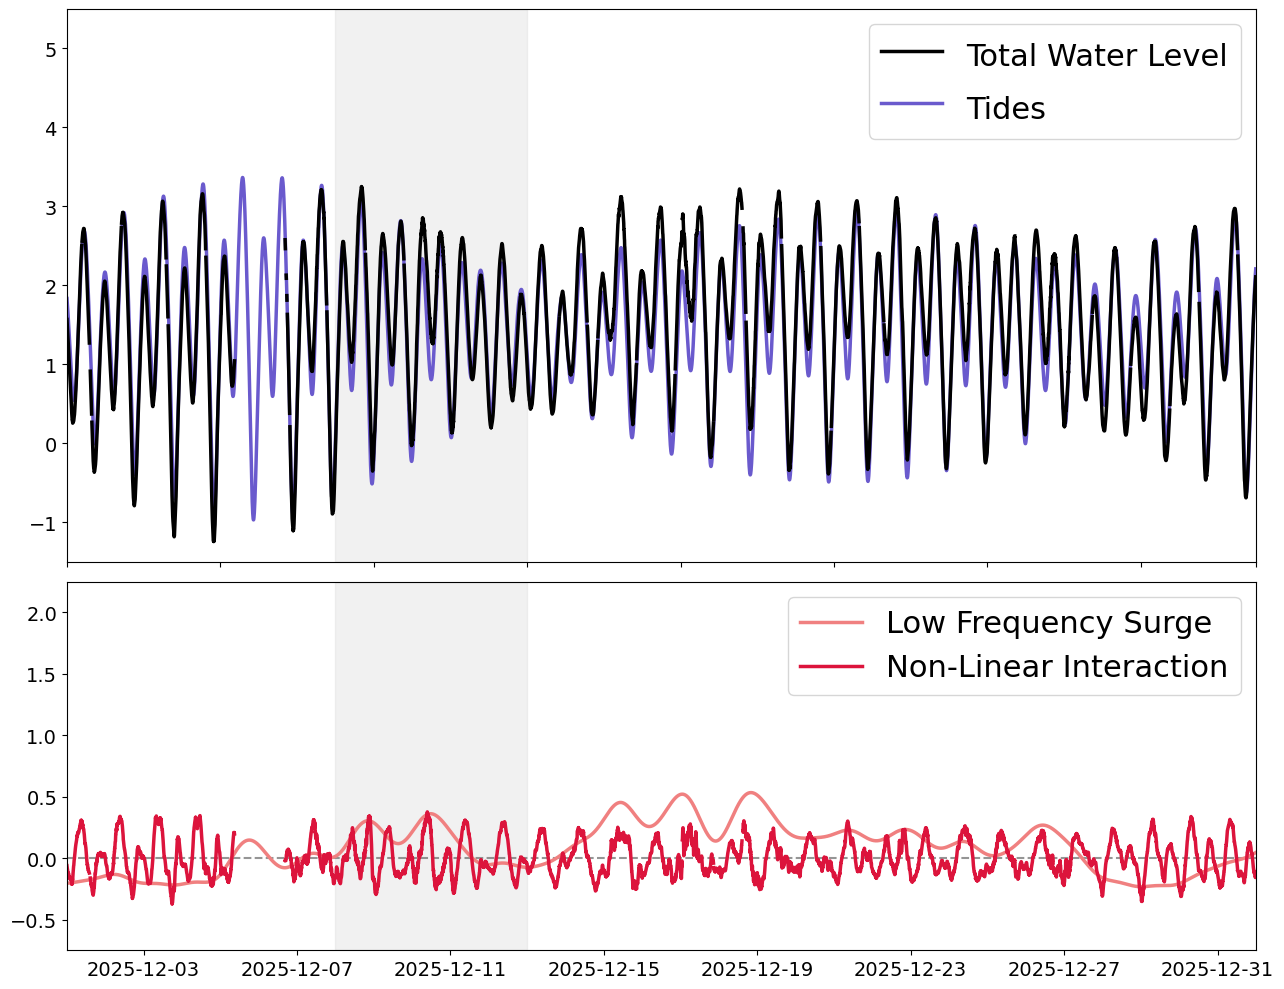

In [226]:
fig = plt.figure(figsize=(13, 10))
gs = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[6, 4])
axes = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

axes[0].plot(wr01_dt_dec, wr01_TIDE_dec, label="Tides", color="slateblue", linewidth=2.5)
axes[0].plot(wr01_dt_dec, wr01_TWL_dec, label="Total Water Level", color="black", linewidth=2.5)
axes[0].set_ylim(-1.5, 5.5)

order = ["Total Water Level", "Tides"]
handles, labels = axes[0].get_legend_handles_labels()
handles_ordered = [handles[labels.index(label)] for label in order]
axes[0].legend(handles_ordered, order, loc="upper right", fontsize=22, handlelength=2, handleheight=1.5)
axes[0].tick_params(labelbottom=False)

axes[1].axhline(y=0, color='dimgrey', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].plot(wr01_dt_dec, wr01_LFS_dec, label="Low Frequency Surge", color="lightcoral", linewidth=2.5)
axes[1].plot(wr01_dt_dec, wr01_NLI_dec, label="Non-Linear Interaction", color="crimson", linewidth=2.5)
axes[1].set_ylim(-0.75, 2.25)
axes[1].legend(loc="upper right", fontsize=22)
# axes[1].set_xlabel("Datetime [LST]")
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=4))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# fig.suptitle("WR01 Dec 2025 Signal Decomposition")
# fig.supylabel("WSE NAVD88 [m]", fontsize=plt.rcParams['axes.labelsize'])

shade_start = pd.Timestamp('2025-12-08')
shade_end = pd.Timestamp('2025-12-13')
for ax in axes:
    ax.set_xlim(pd.Timestamp('2025-12-01'), pd.Timestamp('2026-01-01'))
    ax.axvspan(shade_start, shade_end, alpha=0.3, color='lightgrey', zorder=0)
    ax.tick_params(labelsize=14)

fig.tight_layout()

## WR03

In [94]:
wr03_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WR03_260308201320_FS029.CSV"
wr03_df = pd.read_csv(wr03_file, encoding='latin-1', skiprows=51, skipfooter=1, engine='python')

## Trim data
wr03_df.head() # 35208
wr03_df_trim = wr03_df[26:35200].copy()
wr03_df_trim['Date/time'] = pd.to_datetime(wr03_df_trim['Date/time'])
wr03_df_trim.iloc[19080-26:19114-26, wr03_df_trim.columns.get_loc('Pressure[cmH2O]')] = np.nan  # erroneous values
wr03_df_trim.iloc[11052-26:11060-26, wr03_df_trim.columns.get_loc('Pressure[cmH2O]')] = np.nan  # erroneous values

## Convert to TWL NAVD88

wr03_df_trim['Pressure[cmH2O]'] = wr03_df_trim['Pressure[cmH2O]'].interpolate(method='linear')
wr03_df_trim['Date/time'] = pd.to_datetime(wr03_df_trim['Date/time'])
wr03_df_trim['DateTime_PST'] = wr03_df_trim['Date/time'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)

g = 9.81 # m/s^2
salinity = 0.5 # PSU approx based on CTD data
wr03_df_trim["Rho[kg/m^3]"] = density(wr03_df_trim["Temperature[°C]"], salinity)

wr03_absp_Pa = cmH2O_to_Pa(wr03_df_trim["Pressure[cmH2O]"], wr03_df_trim["Temperature[°C]"], salinity)
wr03_df_trim["AbsPressure[Pa]"] = wr03_absp_Pa

wr03_itp_metp = itp_noaa_metdata(met_df_5min, wr03_df_trim["Date/time"])
wr03_df_trim["MetPressure[Pa]"] = wr03_itp_metp.values

wr03_df_trim["TWL[m]"] = (wr03_df_trim["AbsPressure[Pa]"] - wr03_df_trim["MetPressure[Pa]"]) / (wr03_df_trim["Rho[kg/m^3]"] * g)
wr03_df_trim["TWL[m]"] = np.where(wr03_df_trim["TWL[m]"] < 0, np.nan, wr03_df_trim["TWL[m]"])

wr03_df_trim["TWLNAVD88[m]"] = wr03_df_trim["TWL[m]"] - 1.095

wr03_df_trim.head()

,Date/time,Pressure[cmH2O],Temperature[°C],DateTime_PST,Rho[kg/m^3],AbsPressure[Pa],MetPressure[Pa],TWL[m],TWLNAVD88[m]
26,2025-11-06 16:10:00,1233.875,10.633,2025-11-06 08:10:00,1000.081829,121053.042307,100756.666667,2.068778,0.973778
27,2025-11-06 16:15:00,1238.367,10.623,2025-11-06 08:15:00,1000.082791,121493.860425,100755.000000,2.113878,1.018878
28,2025-11-06 16:20:00,1243.558,10.617,2025-11-06 08:20:00,1000.083367,122003.210018,100753.333333,2.165964,1.070964
29,2025-11-06 16:25:00,1249.217,10.610,2025-11-06 08:25:00,1000.084039,122558.486553,100751.666667,2.222731,1.127731
30,2025-11-06 16:30:00,1254.992,10.610,2025-11-06 08:30:00,1000.084039,123125.061663,100750.000000,2.280651,1.185651


In [95]:
### Implement UTide and obtain TSL

wr03_lat = 46.68073986
wr03_dt = pd.to_datetime(wr03_df_trim["DateTime_PST"])
wr03_TWL = wr03_df_trim["TWLNAVD88[m]"].values

coef_wr03 = solve( wr03_dt, wr03_TWL, lat=wr03_lat, method='ols', phase='Greenwich') 

wr03_utide_summary = pd.DataFrame({'Constituent': coef_wr03['name'], 'Amplitude': coef_wr03['A'], 'Phase': coef_wr03['g']})

recon_wr03 = reconstruct(wr03_dt, coef_wr03)

wr03_TSL = wr03_TWL - recon_wr03.h

solve: matrix prep ... solution ... done.
prep/calcs ... done.


In [98]:
### Implement low pass filter to obtain LFS

# interpolate over NaNs
position = np.arange(len(wr03_TSL))
data_exists = ~np.isnan(wr03_TSL)
wr03_TSL_itp = np.interp(position, position[data_exists], wr03_TSL[data_exists])

# sampling frequency
dt = 5/60 # to match sampling frequency of sensor
fs = 1 / dt

# cutoff frequency
cutoff_period = 35 # hours
cutoff_freq = 1 / cutoff_period

# Nyquist frequency
nyquist = fs / 2

# normalized cutoff frequency
Wn = cutoff_freq / nyquist

# implement butterworth
N = 4 # increase if tidal signals get through
butter_coef1, butter_coef2 = scipy.signal.butter(N, Wn, btype="low")

# apply filter
wr03_LFS = scipy.signal.filtfilt(butter_coef1, butter_coef2, wr03_TSL_itp)

In [99]:
# Obtain NLI

wr03_NLI = wr03_TSL - wr03_LFS

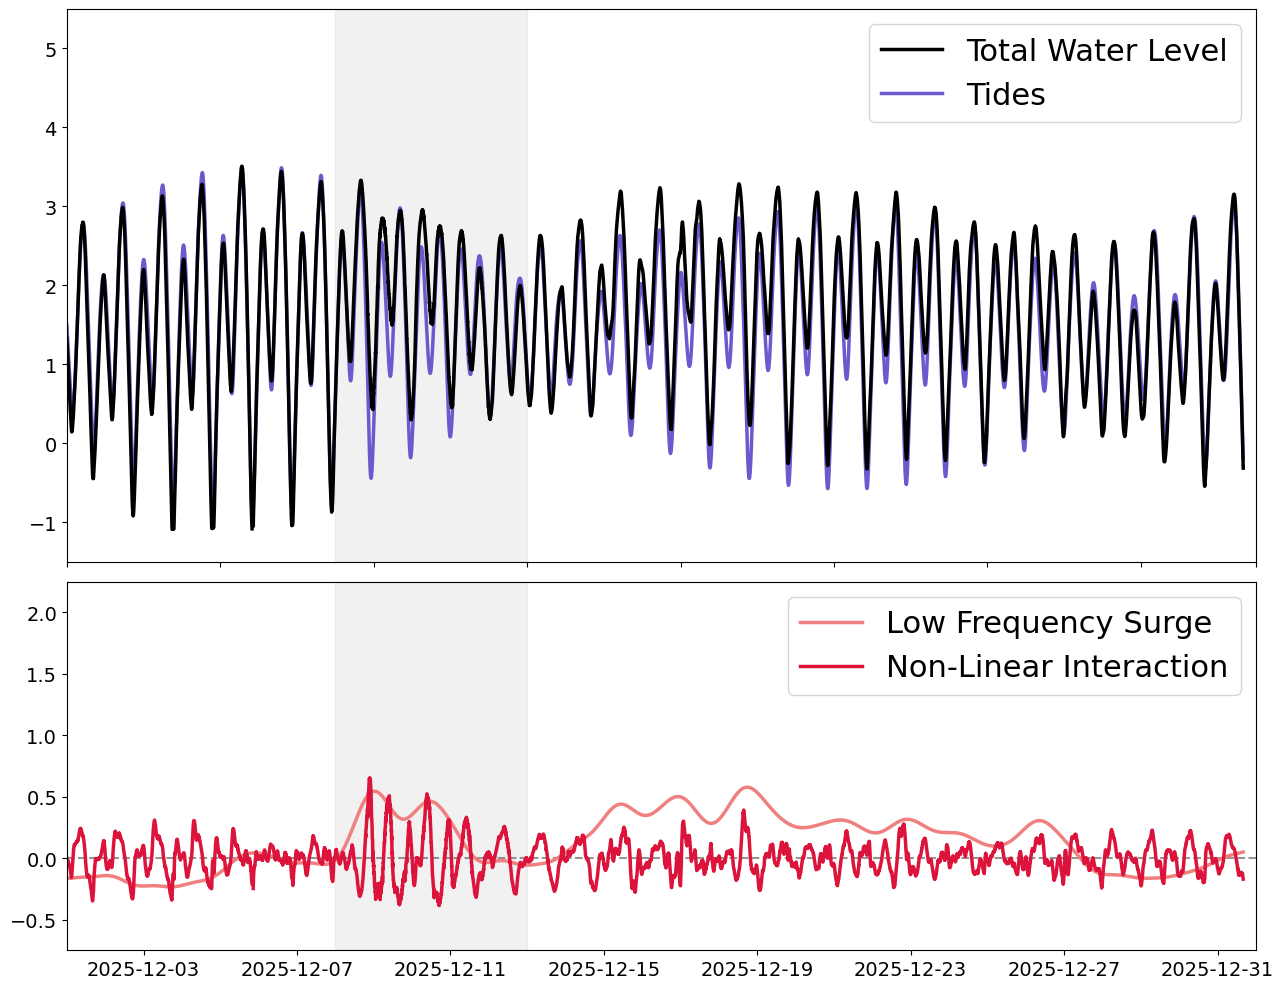

In [222]:
wr03_dt_dec = wr03_dt[7008:15935+1]
wr03_TWL_dec = wr03_TWL[7008:15935+1]
wr03_NLI_dec = wr03_NLI[7008:15935+1]
wr03_TIDE_dec = recon_wr03.h[7008:15935+1]
wr03_LFS_dec = wr03_LFS[7008:15935+1]

fig = plt.figure(figsize=(13, 10))

gs = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[6, 4])
axes = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

axes[0].plot(wr03_dt_dec, wr03_TIDE_dec, label="Tides", color="slateblue", linewidth=2.5)
axes[0].plot(wr03_dt_dec, wr03_TWL_dec, label="Total Water Level", color="black", linewidth=2.5)
axes[0].set_ylim(-1.5, 5.5)
order = ["Total Water Level", "Tides"]
handles, labels = axes[0].get_legend_handles_labels()
handles_ordered = [handles[labels.index(label)] for label in order]
axes[0].legend(handles_ordered, order, loc="upper right", fontsize=22)
axes[0].tick_params(labelbottom=False)

axes[1].axhline(y=0, color='dimgrey', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].plot(wr03_dt_dec, wr03_LFS_dec, label="Low Frequency Surge", color="lightcoral", linewidth=2.5)
axes[1].plot(wr03_dt_dec, wr03_NLI_dec, label="Non-Linear Interaction", color="crimson", linewidth=2.5)
axes[1].set_ylim(-0.75, 2.25)
axes[1].legend(fontsize=22)

# fig.supylabel("WSE NAVD88 [m]", fontsize=plt.rcParams['axes.labelsize'])
# fig.suptitle("WR03 Dec 2025 Signal Decomposition")
# axes[1].set_xlabel("Datetime [LST]")
# Shade December 8-12 in light grey
shade_start = pd.Timestamp('2025-12-08')
shade_end = pd.Timestamp('2025-12-13')
for ax in axes:
    ax.set_xlim(pd.Timestamp('2025-12-01'), pd.Timestamp('2026-01-01'))
    ax.axvspan(shade_start, shade_end, alpha=0.3, color='lightgrey', zorder=0)
    ax.tick_params(labelsize=14)

axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=4))  # Every 4 days
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

fig.tight_layout()

## WR07

In [105]:
wr07_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/WR07_CTD.txt"
wr07_df = pd.read_csv(wr07_file, sep=',', skiprows=[0, 2], header=0)

wr07_df.columns = wr07_df.columns.str.strip()
wr07_df = wr07_df[~wr07_df['Date'].str.contains('-', na=False)]

wr07_df['DateTime'] = pd.to_datetime(wr07_df['Date'] + ' ' + wr07_df['Time'])

wr07_df = wr07_df.reset_index(drop=True)

wr07_df["Press"] = pd.to_numeric(wr07_df["Press"], errors='coerce')

wr07_df_trim = wr07_df.iloc[27:13910]
wr07_df_trim = wr07_df_trim.reset_index(drop=True)

wr07_df_trim["Press_Pa"] = wr07_df_trim["Press"] * 6894.76
wr07_df_trim['DateTime'] = pd.to_datetime(wr07_df_trim['DateTime'])
wr07_df_trim['DateTime_PST'] = wr07_df_trim['DateTime'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)
wr07_df_trim["Temp"] = pd.to_numeric(wr07_df_trim["Temp"], errors='coerce')

salinity = 0 # PSU approx based on CTD data
wr07_df_trim["Rho[kg/m^3]"] = density(wr07_df_trim["Temp"], salinity)
g = 9.81

wr07_itp_metp = itp_noaa_metdata(met_df_5min, wr07_df_trim["DateTime"])
wr07_df_trim["MetPressure[Pa]"] = wr07_itp_metp.values

wr07_df_trim["TWL[m]"] = (wr07_df_trim["Press_Pa"] - wr07_df_trim["MetPressure[Pa]"]) / (wr07_df_trim["Rho[kg/m^3]"] * g)
wr07_df_trim["TWL[m]"] = np.where(wr07_df_trim["TWL[m]"] < 0, np.nan, wr07_df_trim["TWL[m]"])

wr07_df_trim["TWLNAVD88[m]"] = wr07_df_trim["TWL[m]"] + 0.124 # meters

wr07_df_trim.head()

,Date,Time,Temp,SpCond,TDS,Sal,Press,Depth,Battery,DateTime,Press_Pa,DateTime_PST,Rho[kg/m^3],MetPressure[Pa],TWL[m],TWLNAVD88[m]
0,2025/11/25,19:15:08,7.68,0.077,0.050,0.04,16.462,1.238,6.4,2025-11-25 19:15:08,113501.53912,2025-11-25 11:15:08,999.895108,101795.833333,1.193367,1.317367
1,2025/11/25,19:20:08,7.67,0.077,0.050,0.04,16.515,1.275,6.4,2025-11-25 19:20:08,113866.96140,2025-11-25 11:20:08,999.895665,101797.500000,1.230451,1.354451
2,2025/11/25,19:25:08,7.67,0.078,0.050,0.04,16.569,1.313,6.4,2025-11-25 19:25:08,114239.27844,2025-11-25 11:25:08,999.895665,101799.166667,1.268237,1.392237
3,2025/11/25,19:30:08,7.67,0.077,0.050,0.04,16.626,1.353,6.4,2025-11-25 19:30:08,114632.27976,2025-11-25 11:30:08,999.895665,101800.000000,1.308218,1.432218
4,2025/11/25,19:35:08,7.67,0.076,0.049,0.04,16.674,1.387,6.4,2025-11-25 19:35:08,114963.22824,2025-11-25 11:35:08,999.895665,101800.000000,1.341957,1.465957


In [107]:
### Implement UTide and obtain TSL

wr07ctd_df = wr07_df_trim

wr07ctd_lat = 46.66497456
wr07ctd_dt = pd.to_datetime(wr07_df_trim["DateTime_PST"])
wr07ctd_TWL = wr07_df_trim["TWLNAVD88[m]"].values

coef_wr07ctd = solve( wr07ctd_dt, wr07ctd_TWL, lat=wr07ctd_lat, method='ols', phase='Greenwich') 

wr07ctd_utide_summary = pd.DataFrame({'Constituent': coef_wr07ctd['name'], 'Amplitude': coef_wr07ctd['A'], 'Phase': coef_wr07ctd['g']})

recon_wr07ctd = reconstruct(wr07ctd_dt, coef_wr07ctd)

wr07ctd_TSL = wr07ctd_TWL - recon_wr07ctd.h

solve: matrix prep ... solution ... done.
prep/calcs ... done.


In [109]:
### Implement low pass filter to obtain LFS

# interpolate over NaNs
position = np.arange(len(wr07ctd_TSL))
data_exists = ~np.isnan(wr07ctd_TSL)
wr07ctd_TSL_itp = np.interp(position, position[data_exists], wr07ctd_TSL[data_exists])

# sampling frequency
dt = 5/60 # to match sampling frequency of sensor
fs = 1 / dt

# cutoff frequency
cutoff_period = 35 # hours
cutoff_freq = 1 / cutoff_period

# Nyquist frequency
nyquist = fs / 2

# normalized cutoff frequency
Wn = cutoff_freq / nyquist

# implement butterworth
N = 4 # increase if tidal signals get through
butter_coef1, butter_coef2 = scipy.signal.butter(N, Wn, btype="low")

# apply filter
wr07ctd_LFS = scipy.signal.filtfilt(butter_coef1, butter_coef2, wr07ctd_TSL_itp)

In [111]:
# Obtain NLI

wr07ctd_NLI = wr07ctd_TSL - wr07ctd_LFS

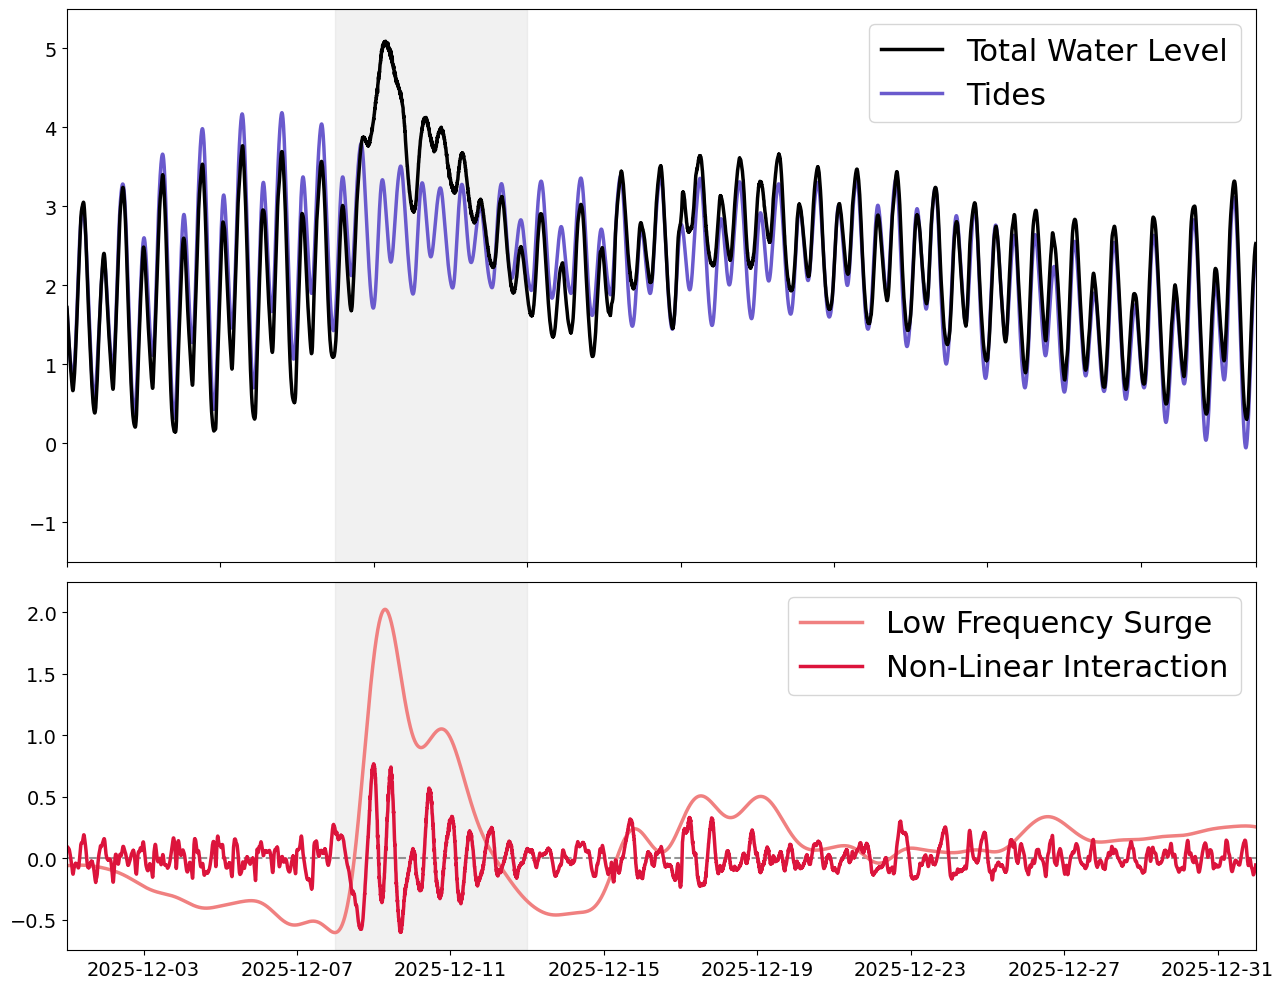

In [254]:
december_mask = (wr07ctd_df["DateTime_PST"] >= '2025-12-01') & (wr07ctd_df["DateTime_PST"] < '2026-01-01')
wr07ctd_dt_dec = wr07ctd_df[december_mask]["DateTime_PST"]

wr07ctd_dec_df = wr07ctd_df[december_mask]
wr07ctd_TWL_dec = wr07ctd_TWL[december_mask]
wr07ctd_TIDE_dec = recon_wr07ctd.h[december_mask]
wr07ctd_LFS_dec = wr07ctd_LFS[december_mask]
wr07ctd_NLI_dec = wr07ctd_NLI[december_mask]

fig = plt.figure(figsize=(13, 10))
gs = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[6, 4])
axes = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]


axes[0].plot(wr07ctd_dt_dec, wr07ctd_TIDE_dec, label="Tides", color="slateblue", linewidth=2.5)
axes[0].plot(wr07ctd_dt_dec, wr07ctd_TWL_dec, label="Total Water Level", color="black", linewidth=2.5)
axes[0].set_ylim(-1.5, 5.5)
order = ["Total Water Level", "Tides"]
handles, labels = axes[0].get_legend_handles_labels()
handles_ordered = [handles[labels.index(label)] for label in order]
axes[0].legend(handles_ordered, order, loc="upper right", fontsize=22)
axes[0].tick_params(labelbottom=False)

axes[1].axhline(y=0, color='dimgrey', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].plot(wr07ctd_dt_dec, wr07ctd_LFS_dec, label="Low Frequency Surge", color="lightcoral", linewidth=2.5)
axes[1].plot(wr07ctd_dt_dec, wr07ctd_NLI_dec, label="Non-Linear Interaction", color="crimson", linewidth=2.5)
axes[1].set_ylim(-0.75, 2.25)
axes[1].legend(loc="upper right", fontsize=22)

# Shade December 8-12 in light grey
shade_start = pd.Timestamp('2025-12-08')
shade_end = pd.Timestamp('2025-12-13')

for ax in axes:
    ax.set_xlim(pd.Timestamp('2025-12-01'), pd.Timestamp('2026-01-01'))
    ax.axvspan(shade_start, shade_end, alpha=0.3, color='lightgrey', zorder=0)
    ax.tick_params(labelsize=14)

# fig.suptitle("WR07 Dec 2025 Signal Decomposition")
# fig.supylabel("WSE NAVD88 [m]", fontsize=plt.rcParams['axes.labelsize'])
# axes[1].set_xlabel("Datetime [LST]")
# Reduce x-axis ticks to prevent overlap
import matplotlib.dates as mdates
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=4))  # Every 4 days
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

fig.tight_layout()

## WR02

In [256]:
# Update

wr02_novdec_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/RaymondNovDec.xlsx"
wr02_janfeb_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/RaymondJanFeb.xlsx"
wr02_marapr_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/RaymondMarApr.xlsx"

wr02_novdec_df = pd.read_excel(wr02_novdec_file, skiprows=1)
wr02_janfeb_df = pd.read_excel(wr02_janfeb_file, skiprows=1,)
wr02_marapr_df = pd.read_excel(wr02_marapr_file, skiprows=1)
wr02_df = pd.concat([wr02_novdec_df, wr02_janfeb_df, wr02_marapr_df], ignore_index=True)

# data cleaning
wr02_df["SWE NAVD88 (m)"] = (wr02_df["Level/Stage (ft)"] * 0.3048) - 0.427  # in m NAVD88

# Only convert and sort if Date&Time is still a column (not already the index)
if 'Date&Time' in wr02_df.columns:
    wr02_df['Date&Time'] = pd.to_datetime(wr02_df["Date&Time"], format="%m/%d/%Y %I:%M:%S %p")
    wr02_df = wr02_df.sort_values('Date&Time').reset_index(drop=True)
    wr02_df = wr02_df.iloc[100:].reset_index(drop=True)
    wr02_df = wr02_df.set_index('Date&Time')

wr02_df = wr02_df.asfreq('5min')
wr02_df.loc['2025-12-05 08:55:00':'2025-12-06 15:10:00', 'SWE NAVD88 (m)'] = np.nan
wr02_dt = wr02_df.index
wr02_twl = wr02_df["SWE NAVD88 (m)"]
wr02_df.head()

,Location,Data Sent,isDeleted,Level/Stage (ft),L1,L2,L3,L4,L5,SWE NAVD88 (m)
Date&Time,,,,,,,,,,
2025-11-07 22:00:00,Raymond,False,False,0.30,19.70,19.70,19.70,19.71,19.70,-0.335560
2025-11-07 22:05:00,Raymond,False,False,0.34,19.66,19.66,19.66,19.66,19.67,-0.323368
2025-11-07 22:10:00,Raymond,False,False,0.44,19.56,19.58,19.56,19.56,19.56,-0.292888
2025-11-07 22:15:00,Raymond,False,False,0.54,19.46,19.47,19.46,19.46,19.46,-0.262408
2025-11-07 22:20:00,Raymond,False,False,0.66,19.34,19.35,19.35,19.34,19.34,-0.225832


In [257]:
### Implement UTide and obtain TSL

wr02_lat = 46.68904
wr02_dt = wr02_df.index
wr02_TWL = wr02_df["SWE NAVD88 (m)"].values

coef_wr02 = solve(wr02_dt, wr02_TWL, lat=wr02_lat, method='ols', phase='Greenwich')

wr02_utide_summary = pd.DataFrame({'Constituent': coef_wr02['name'], 'Amplitude': coef_wr02['A'], 'Phase': coef_wr02['g']})

recon_wr02 = reconstruct(wr02_dt, coef_wr02)

wr02_TSL = wr02_TWL - recon_wr02.h

solve: matrix prep ... solution ... done.
prep/calcs ... done.


In [258]:
### Implement low pass filter to obtain LFS

# interpolate over NaNs
position = np.arange(len(wr02_TSL))
data_exists = ~np.isnan(wr02_TSL)
wr02_TSL_itp = np.interp(position, position[data_exists], wr02_TSL[data_exists])

# sampling frequency
dt = 5/60 # to match sampling frequency of sensor
fs = 1 / dt

# cutoff frequency
cutoff_period = 35 # hours
cutoff_freq = 1 / cutoff_period

# Nyquist frequency
nyquist = fs / 2

# normalized cutoff frequency
Wn = cutoff_freq / nyquist

# implement butterworth
N = 4 # increase if tidal signals get through
butter_coef1, butter_coef2 = scipy.signal.butter(N, Wn, btype="low")

# apply filter
wr02_LFS = scipy.signal.filtfilt(butter_coef1, butter_coef2, wr02_TSL_itp)

In [259]:
### Obtain NLI

wr02_NLI = wr02_TSL - wr02_LFS

## WR04

In [261]:
# Update

wr04_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WR04_260308201401_FS064.CSV"

wr04_df = pd.read_csv(wr04_file, encoding='latin-1', skiprows=51, skipfooter=1, engine='python')

wr04_df_trim = wr04_df[20:35194].copy()
wr04_df_trim['Date/time'] = pd.to_datetime(wr04_df_trim['Date/time'])
wr04_df_trim.iloc[19063:19096, wr04_df_trim.columns.get_loc('Pressure[cmH2O]')] = np.nan # erroneous values

wr04_df_trim['Pressure[cmH2O]'] = wr04_df_trim['Pressure[cmH2O]'].interpolate(method='linear')
wr04_df_trim['Date/time'] = pd.to_datetime(wr04_df_trim['Date/time'])
wr04_df_trim['DateTime_PST'] = wr04_df_trim['Date/time'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)

g = 9.81 # m/s^2
salinity = 0.5 # PSU approx based on CTD data
wr04_df_trim["Rho[kg/m^3]"] = density(wr04_df_trim["Temperature[°C]"], salinity)

wr04_absp_Pa = cmH2O_to_Pa(wr04_df_trim["Pressure[cmH2O]"], wr04_df_trim["Temperature[°C]"], salinity)
wr04_df_trim["AbsPressure[Pa]"] = wr04_absp_Pa

wr04_itp_metp = itp_noaa_metdata(met_df_5min, wr04_df_trim["Date/time"])
wr04_df_trim["MetPressure[Pa]"] = wr04_itp_metp.values

wr04_df_trim["TWL[m]"] = (wr04_df_trim["AbsPressure[Pa]"] - wr04_df_trim["MetPressure[Pa]"]) / (wr04_df_trim["Rho[kg/m^3]"] * g)
wr04_df_trim["TWL[m]"] = np.where(wr04_df_trim["TWL[m]"] < 0, np.nan, wr04_df_trim["TWL[m]"])

wr04_df_trim["TWLNAVD88[m]"] = wr04_df_trim["TWL[m]"] - 1.046 # sticking w/ initial elev and ignoring 0.5" slide for now

wr04_dt = wr04_df_trim["DateTime_PST"]
wr04_twl = wr04_df_trim["TWLNAVD88[m]"]

wr04_df_trim.head()

,Date/time,Pressure[cmH2O],Temperature[°C],DateTime_PST,Rho[kg/m^3],AbsPressure[Pa],MetPressure[Pa],TWL[m],TWLNAVD88[m]
20,2025-11-06 15:40:00,1214.392,10.673,2025-11-06 07:40:00,1000.077968,119141.143654,100760.0,1.873569,0.827569
21,2025-11-06 15:45:00,1215.208,10.673,2025-11-06 07:45:00,1000.077968,119221.199495,100760.0,1.881729,0.835729
22,2025-11-06 15:50:00,1216.783,10.657,2025-11-06 07:50:00,1000.079515,119375.903688,100760.0,1.897495,0.851495
23,2025-11-06 15:55:00,1219.292,10.650,2025-11-06 07:55:00,1000.080190,119622.136981,100760.0,1.922592,0.876592
24,2025-11-06 16:00:00,1222.850,10.667,2025-11-06 08:00:00,1000.078548,119971.007781,100760.0,1.958155,0.912155


In [262]:
### Implement UTide and obtain TSL

wr04_lat = 46.68409
wr04_dt = pd.to_datetime(wr04_df_trim["DateTime_PST"])
wr04_TWL = wr04_twl.values
coef_wr04 = solve(wr04_dt, wr04_TWL, lat=wr04_lat, method='ols', phase='Greenwich')

wr04_utide_summary = pd.DataFrame({'Constituent': coef_wr04['name'], 'Amplitude': coef_wr04['A'], 'Phase': coef_wr04['g']})

recon_wr04 = reconstruct(wr04_dt, coef_wr04)

wr04_TSL = wr04_TWL - recon_wr04.h

solve: matrix prep ... solution ... done.
prep/calcs ... done.


In [263]:
### Implement low pass filter to obtain LFS

# interpolate over NaNs
position = np.arange(len(wr04_TSL))
data_exists = ~np.isnan(wr04_TSL)
wr04_TSL_itp = np.interp(position, position[data_exists], wr04_TSL[data_exists])

# sampling frequency
dt = 5/60 # to match sampling frequency of sensor
fs = 1 / dt

# cutoff frequency
cutoff_period = 35 # hours
cutoff_freq = 1 / cutoff_period

# Nyquist frequency
nyquist = fs / 2

# normalized cutoff frequency
Wn = cutoff_freq / nyquist

# implement butterworth
N = 4 # increase if tidal signals get through
butter_coef1, butter_coef2 = scipy.signal.butter(N, Wn, btype="low")

# apply filter
wr04_LFS = scipy.signal.filtfilt(butter_coef1, butter_coef2, wr04_TSL_itp)

In [264]:
### Obtain NLI

wr04_NLI = wr04_TSL - wr04_LFS

## WR06

In [275]:
wr06_p1_d5_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WR06_InSitu632743brackish_2026-01-11_13-47-47-563.csv"
wr06_p2_d5_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WR06_InSitu642743brackishJan11dep_2026-03-08_13-08-58-922.txt"
wr06_ctd_d5_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WR06_RED_030826.txt"
wr06_ctd_d3_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/Copy of CTD_WR06_12.14retrieval.txt"

wr06_p1_d5_df = pd.read_csv(wr06_p1_d5_file, skiprows=70)
wr06_p2_d5_df = pd.read_fwf(wr06_p2_d5_file, encoding='utf-16', skiprows=71)
wr06_ctd_d5_df = pd.read_csv(wr06_ctd_d5_file, skiprows=4,
                               names=['Date', 'Time', 'Temp', 'SpCond', 'Sal', 'Press', 'Depth', 'Battery'])
wr06_ctd_d3_df = pd.read_csv(wr06_ctd_d3_file, sep=',', skiprows=[0, 2], header=0)

# pressure p1
# this was the other in-situ that had the time offset!!
wr06_p1_d5_df = pd.read_csv(wr06_p1_d5_file, skiprows=70)
wr06_p1_d5_df_trim = wr06_p1_d5_df[275:8290].copy().rename(columns={
    'Date and Time': 'DateTime',
    'Pressure (PSI)                          ': 'Pressure_PSI',
    'Temperature (F)                         ': 'Temp_F',
    'Depth (ft)                              ': 'Depth_ft'})

wr06_p1_d5_df_trim['DateTime'] = pd.to_datetime(wr06_p1_d5_df_trim['DateTime'], format='mixed') 
# correct time offset (internal clock was ahead by this amount)
internal_time = datetime(2026, 1, 12, 4, 56, 41)
real_time = datetime(2026, 1, 11, 13, 55, 25)
offset = internal_time - real_time
wr06_p1_d5_df_trim['DateTime'] = wr06_p1_d5_df_trim['DateTime'] - offset # now in PST

# pressure p2
wr06_p2_d5_df = pd.read_fwf(wr06_p2_d5_file, encoding='utf-16', skiprows=71)
wr06_p2_d5_df_trim = wr06_p2_d5_df[14:16088].copy()
wr06_p2_d5_df_trim.columns = ['DateTime', 'Elapsed_s', 'Temp_F', 'Pressure_PSI', 'Depth_ft']
wr06_p2_d5_df_trim['DateTime'] = pd.to_datetime(wr06_p2_d5_df_trim['DateTime'], format='%m/%d/%Y %I:%M:%S %p') # in PST

# combine (24089 length)
wr06_p_df_trim = pd.concat([wr06_p1_d5_df_trim[['DateTime', 'Pressure_PSI', 'Temp_F', 'Depth_ft']], 
                        wr06_p2_d5_df_trim[['DateTime', 'Pressure_PSI', 'Temp_F', 'Depth_ft']]]).sort_values('DateTime').reset_index(drop=True)

## Convert to TWL NAVD88

wr06_p_df_trim['Pressure_PSI'] = wr06_p_df_trim['Pressure_PSI'].interpolate(method='linear')
wr06_p_df_trim["Temp_C"] = (wr06_p_df_trim["Temp_F"] - 32) * 5/9

g = 9.81 # m/s^2
PSI_to_Pa = 6894.76  # 1 PSI = 6894.76 Pa
salinity = 0.5 # PSU approx based on CTD data

wr06_p_df_trim["AbsPressure[Pa]"] = wr06_p_df_trim["Pressure_PSI"] * PSI_to_Pa
wr06_p_df_trim["Rho[kg/m^3]"] = density(wr06_p_df_trim["Temp_C"], salinity)

wr06_p_itp_metp = itp_noaa_metdata(met_df_5min, wr06_p_df_trim["DateTime"])
wr06_p_df_trim["MetPressure[Pa]"] = wr06_p_itp_metp.values

wr06_p_df_trim["TWL[m]"] = (wr06_p_df_trim["AbsPressure[Pa]"] - wr06_p_df_trim["MetPressure[Pa]"]) / (wr06_p_df_trim["Rho[kg/m^3]"] * g)
wr06_p_df_trim["TWL[m]"] = np.where(wr06_p_df_trim["TWL[m]"] < 0, np.nan, wr06_p_df_trim["TWL[m]"])

wr06_p_df_trim["TWLNAVD88[m]"] = wr06_p_df_trim["TWL[m]"] - 1.154
wr06_p_df_trim["DateTime_PST"] = wr06_p_df_trim["DateTime"] # for concatenating

wr06_p_df_trim.head()

# CTD pre 12/14

# CTD 11/6 - 12/15

# data cleaning
wr06_ctd_d3_df.columns = wr06_ctd_d3_df.columns.str.strip()
wr06_ctd_d3_df = wr06_ctd_d3_df[~wr06_ctd_d3_df['Date'].str.contains('-', na=False)]
wr06_ctd_d3_df['DateTime'] = pd.to_datetime(wr06_ctd_d3_df['Date'] + ' ' + wr06_ctd_d3_df['Time'])

# Convert UTC to PST (UTC-8) and remove timezone info
wr06_ctd_d3_df['DateTime_PST'] = wr06_ctd_d3_df['DateTime'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)

wr06_ctd_d3_df = wr06_ctd_d3_df.reset_index(drop=True)
wr06_ctd_d3_df["Press"] = pd.to_numeric(wr06_ctd_d3_df["Press"], errors='coerce')
wr06_ctd_d3_df = wr06_ctd_d3_df.reset_index(drop=True)
wr06_ctd_d3_df["AbsPressure[Pa]"] = wr06_ctd_d3_df["Press"] * 6894.76

wr06_ctd_d3_df["Temp"] = pd.to_numeric(wr06_ctd_d3_df["Temp"], errors='coerce')

salinity = 0 # PSU approx based on CTD data
wr06_ctd_d3_df["Rho[kg/m^3]"] = density(wr06_ctd_d3_df["Temp"], salinity)
g = 9.81

wr06_ctd_d3_itp_metp = itp_noaa_metdata(met_df_5min, wr06_ctd_d3_df["DateTime_PST"])
wr06_ctd_d3_df["MetPressure[Pa]"] = wr06_ctd_d3_itp_metp.values
wr06_ctd_d3_df["TWL[m]"] = (wr06_ctd_d3_df["AbsPressure[Pa]"] - wr06_ctd_d3_df["MetPressure[Pa]"]) / (wr06_ctd_d3_df["Rho[kg/m^3]"] * g)
wr06_ctd_d3_df["TWL[m]"] = np.where(wr06_ctd_d3_df["TWL[m]"] < 0, np.nan, wr06_ctd_d3_df["TWL[m]"])
wr06_ctd_d3_df["TWLNAVD88[m]"] = wr06_ctd_d3_df["TWL[m]"] - 0.238  # meters

wr06_ctd_d3_df_trim = wr06_ctd_d3_df.iloc[20:11068].copy()
wr06_ctd_d3_df_trim["TWLNAVD88[m]"] = wr06_ctd_d3_df_trim["TWLNAVD88[m]"] - 0.75  # after overlaying wr04 to fix it

wr06_ctd_d3_df_trim.head()

# CTD post 12/14
wr06_ctd_d5_df_trim = wr06_ctd_d5_df[214:].copy()
wr06_ctd_d5_df_trim['DateTime'] = pd.to_datetime(wr06_ctd_d5_df_trim['Date'] + ' ' + wr06_ctd_d5_df_trim['Time'])
wr06_ctd_d5_df_trim.head() # length 23013
wr06_ctd_d5_df_trim.iloc[7945-213:8270-213, wr06_ctd_d5_df_trim.columns.get_loc('Press')] = np.nan # erroneous values

# fig, ax = plt.subplots(figsize=(12,4))
# ax.plot(wr06_ctd_d5_df_trim['DateTime'], wr06_ctd_d5_df_trim['Press']);

wr06_df = pd.concat([wr06_ctd_d3_df_trim, wr06_p_df_trim], ignore_index=True)

wr06_dt = wr06_df["DateTime_PST"]
wr06_twl = wr06_df["TWLNAVD88[m]"]

wr06_df.head()

,Date,Time,Temp,SpCond,Sal,Press,Depth,Battery,DateTime,DateTime_PST,AbsPressure[Pa],Rho[kg/m^3],MetPressure[Pa],TWL[m],TWLNAVD88[m],Pressure_PSI,Temp_F,Depth_ft,Temp_C
0,2025/11/06,15:40:08,10.70,0.102,0.05,17.181,1.736,6.5,2025-11-06 15:40:08,2025-11-06 07:40:08,118458.87156,999.663350,101151.666667,1.764835,0.776835,NaN,NaN,NaN,NaN
1,2025/11/06,15:45:08,10.71,0.101,0.05,17.192,1.744,6.5,2025-11-06 15:45:08,2025-11-06 07:45:08,118534.71392,999.662378,101148.333333,1.772911,0.784911,NaN,NaN,NaN,NaN
2,2025/11/06,15:50:08,10.70,0.102,0.05,17.214,1.760,6.5,2025-11-06 15:50:08,2025-11-06 07:50:08,118686.39864,999.663350,101145.000000,1.788716,0.800716,NaN,NaN,NaN,NaN
3,2025/11/06,15:55:08,10.71,0.102,0.05,17.244,1.780,6.5,2025-11-06 15:55:08,2025-11-06 07:55:08,118893.24144,999.662378,101141.666667,1.810150,0.822150,NaN,NaN,NaN,NaN
4,2025/11/06,16:00:08,10.70,0.102,0.05,17.286,1.810,6.5,2025-11-06 16:00:08,2025-11-06 08:00:08,119182.82136,999.663350,101138.333333,1.840017,0.852017,NaN,NaN,NaN,NaN


In [276]:
wr06_lat = 46.679167
wr06_TWL = wr06_twl.values
coef_wr06 = solve(wr06_dt, wr06_TWL, lat=wr06_lat, method='ols', phase='Greenwich')
wr06_utide_summary = pd.DataFrame({'Constituent': coef_wr06['name'], 'Amplitude': coef_wr06['A'], 'Phase': coef_wr06['g']})

recon_wr06 = reconstruct(wr06_dt, coef_wr06)

wr06_TSL = wr06_TWL - recon_wr06.h

solve: matrix prep ... solution ... done.
prep/calcs ... done.


In [277]:
### Implement low pass filter to obtain LFS

# interpolate over NaNs
position = np.arange(len(wr06_TSL))
data_exists = ~np.isnan(wr06_TSL)
wr06_TSL_itp = np.interp(position, position[data_exists], wr06_TSL[data_exists])

# sampling frequency
dt = 5/60 # to match sampling frequency of sensor
fs = 1 / dt

# cutoff frequency
cutoff_period = 35 # hours
cutoff_freq = 1 / cutoff_period

# Nyquist frequency
nyquist = fs / 2

# normalized cutoff frequency
Wn = cutoff_freq / nyquist

# implement butterworth
N = 4 # increase if tidal signals get through
butter_coef1, butter_coef2 = scipy.signal.butter(N, Wn, btype="low")

# apply filter
wr06_LFS = scipy.signal.filtfilt(butter_coef1, butter_coef2, wr06_TSL_itp)

In [278]:
### Obtain NLI

wr06_NLI = wr06_TSL - wr06_LFS

In [279]:
TPnov_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/TPnov.csv"
TPdec_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/TPdec.csv"
TPjan_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/TPjan.csv"
TPfeb_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/TPfeb.csv"
TPmar_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/TPmar.csv"
TPapr_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/TPapr.csv"

TPnov_df = pd.read_csv(TPnov_file)
TPdec_df = pd.read_csv(TPdec_file)
TPjan_df = pd.read_csv(TPjan_file)
TPfeb_df = pd.read_csv(TPfeb_file)
TPmar_df = pd.read_csv(TPmar_file)
TPapr_df = pd.read_csv(TPapr_file)
TP_df = pd.concat([TPnov_df, TPdec_df, TPjan_df, TPfeb_df, TPmar_df, TPapr_df], ignore_index=True) # LST time and metric and NAVD datum

TP_df['DateTime'] = pd.to_datetime(TP_df['Date'] + ' ' + TP_df['Time (LST/LDT)'])
TP_df['Verified (m)'] = pd.to_numeric(TP_df['Verified (m)'], errors='coerce')

TP_dt = TP_df["DateTime"]
TP_twl = TP_df["Verified (m)"]

TP_lat = 46.70833
TP_TWL = TP_twl.values
coef_TP = solve(TP_dt, TP_TWL, lat=TP_lat, method='ols', phase='Greenwich')
TP_utide_summary = pd.DataFrame({'Constituent': coef_TP['name'], 'Amplitude': coef_TP['A'], 'Phase': coef_TP['g']})
recon_TP = reconstruct(TP_dt, coef_TP)

TP_TSL = TP_TWL - recon_TP.h

### Implement low pass filter to obtain LFS

# interpolate over NaNs
position = np.arange(len(TP_TSL))
data_exists = ~np.isnan(TP_TSL)
TP_TSL_itp = np.interp(position, position[data_exists], TP_TSL[data_exists])

# sampling frequency
dt = 5/60 # to match sampling frequency of sensor
fs = 1 / dt

# cutoff frequency
cutoff_period = 35 # hours
cutoff_freq = 1 / cutoff_period

# Nyquist frequency
nyquist = fs / 2

# normalized cutoff frequency
Wn = cutoff_freq / nyquist

# implement butterworth
N = 4 # increase if tidal signals get through
butter_coef1, butter_coef2 = scipy.signal.butter(N, Wn, btype="low")

# apply filter
TP_LFS = scipy.signal.filtfilt(butter_coef1, butter_coef2, TP_TSL_itp)

### Obtain NLI

TP_NLI = TP_TSL - TP_LFS

solve: matrix prep ... solution ... done.
prep/calcs ... done.


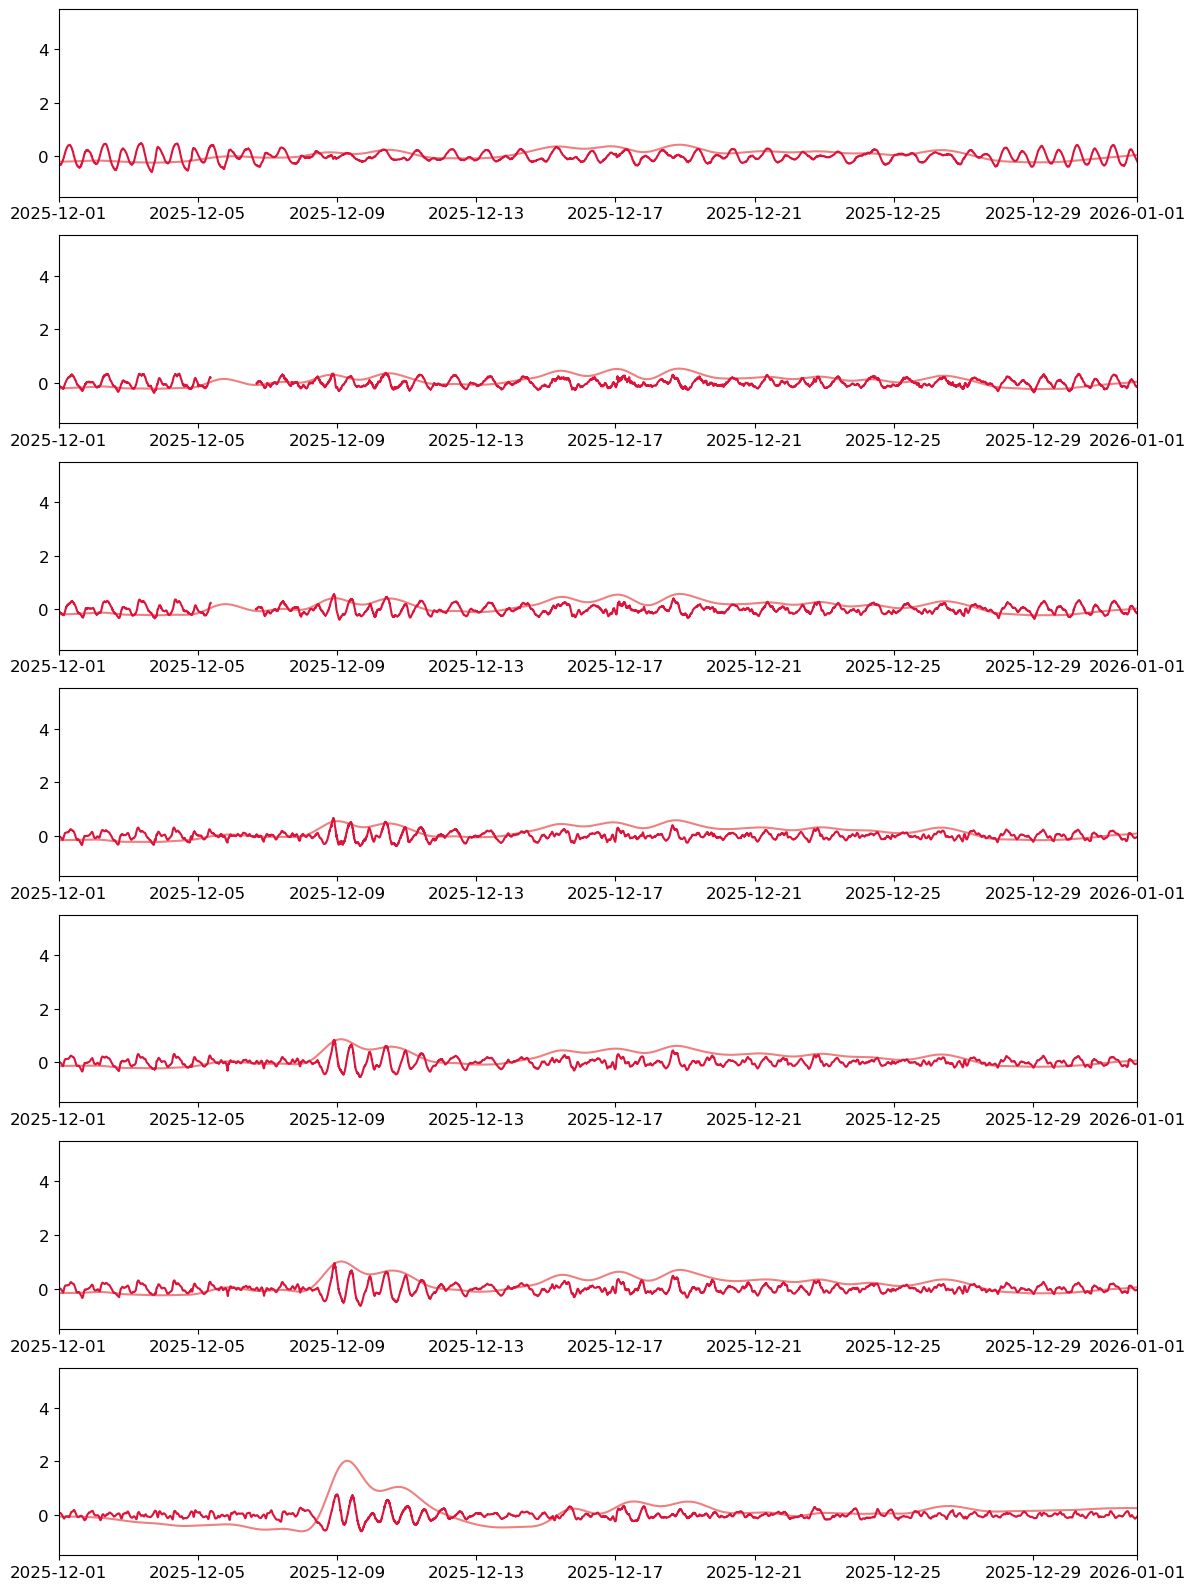

In [286]:
fig, ax = plt.subplots(7, 1, figsize=(12,16))

ax[0].plot(TP_dt, TP_LFS, color='lightcoral')
ax[0].plot(TP_dt, TP_NLI, color='crimson')

ax[1].plot(wr01_dt, wr01_LFS, color='lightcoral')
ax[1].plot(wr01_dt, wr01_NLI, color='crimson')

ax[2].plot(wr02_dt, wr02_LFS, color='lightcoral')
ax[2].plot(wr02_dt, wr02_NLI, color='crimson')

ax[3].plot(wr03_dt, wr03_LFS, color='lightcoral')
ax[3].plot(wr03_dt, wr03_NLI, color='crimson')

ax[4].plot(wr04_dt, wr04_LFS, color='lightcoral')
ax[4].plot(wr04_dt, wr04_NLI, color='crimson')

ax[5].plot(wr06_dt, wr06_LFS, color='lightcoral')
ax[5].plot(wr06_dt, wr06_NLI, color='crimson')

ax[6].plot(wr07ctd_dt, wr07ctd_LFS, color='lightcoral')
ax[6].plot(wr07ctd_dt, wr07ctd_NLI, color='crimson')

fig.tight_layout()

for a in ax:  # use 'a' (or any other name) to avoid clobbering 'ax'
    a.set_xlim(pd.Timestamp('2025-12-01'), pd.Timestamp('2026-01-01'))
    a.set_ylim(-1.5, 5.5)
    a.tick_params(labelsize=12)

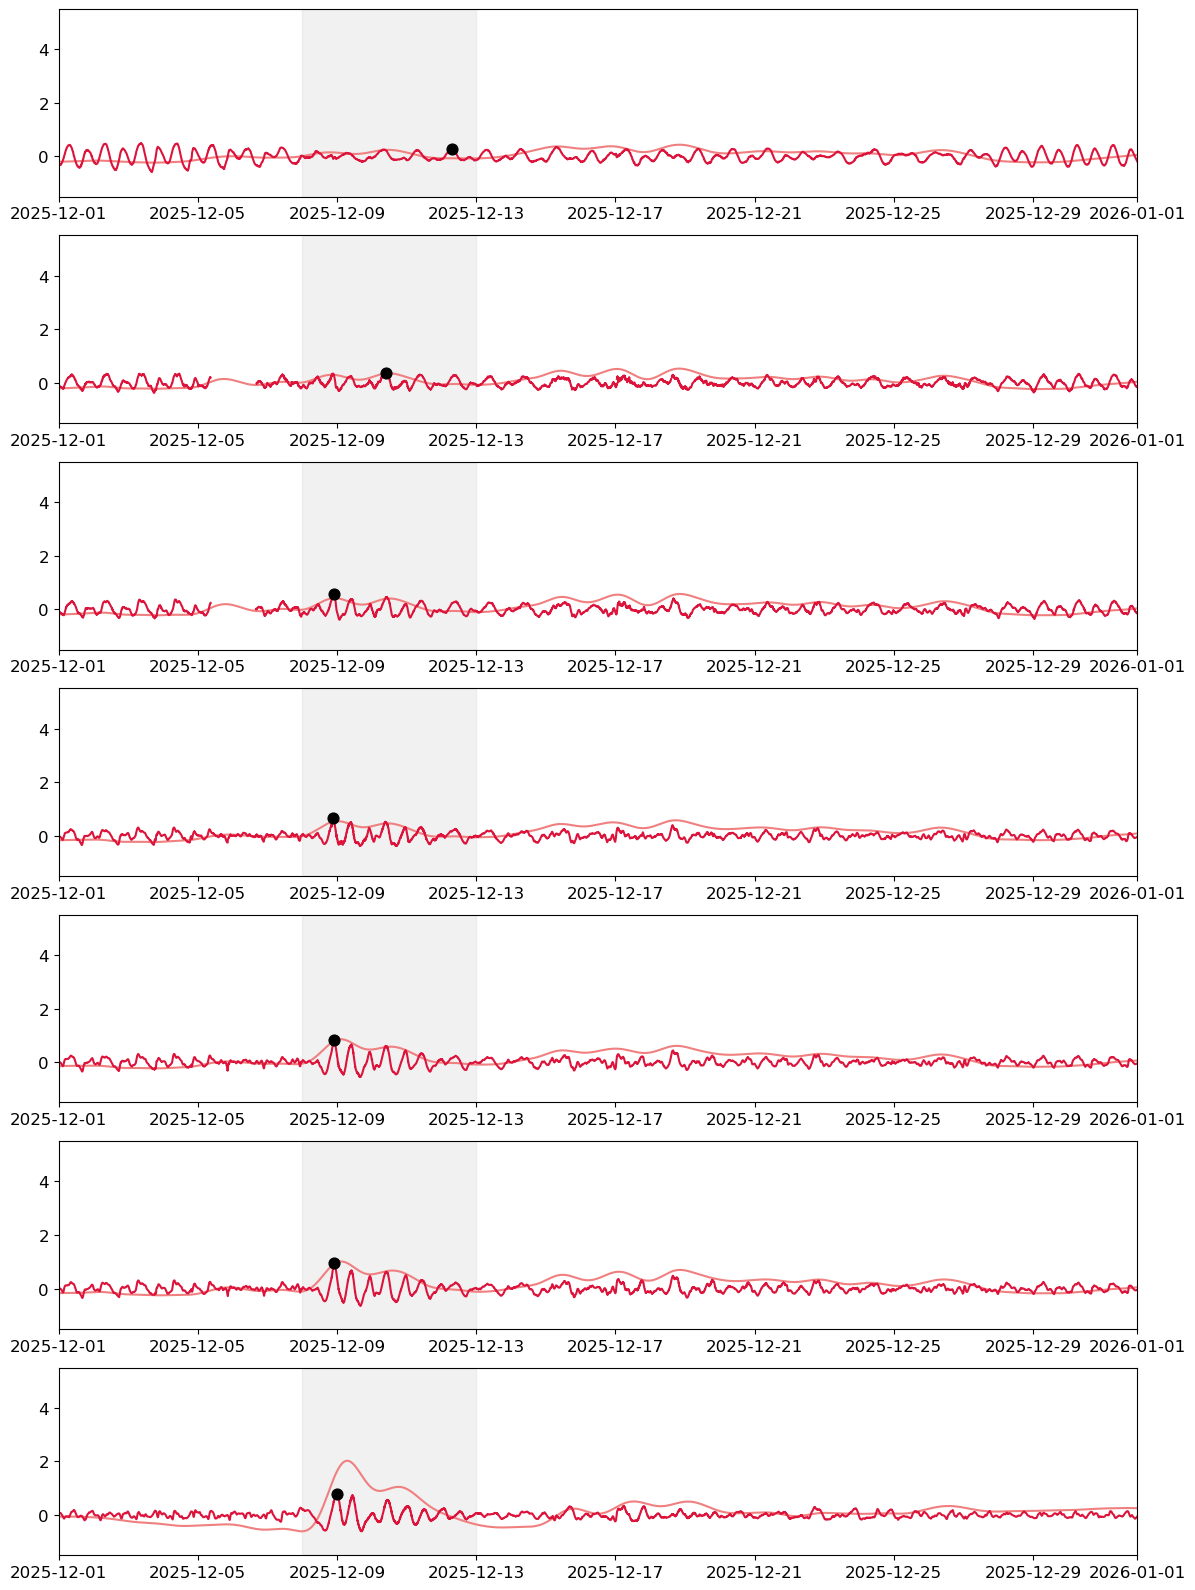

In [287]:
fig, ax = plt.subplots(7, 1, figsize=(12,16))
panels = [
    (TP_dt, TP_LFS, TP_NLI),
    (wr01_dt, wr01_LFS, wr01_NLI),
    (wr02_dt, wr02_LFS, wr02_NLI),
    (wr03_dt, wr03_LFS, wr03_NLI),
    (wr04_dt, wr04_LFS, wr04_NLI),
    (wr06_dt, wr06_LFS, wr06_NLI),
    (wr07ctd_dt, wr07ctd_LFS, wr07ctd_NLI),
]
shade_start = pd.Timestamp('2025-12-08')
shade_end   = pd.Timestamp('2025-12-13')

max_NLI_label = ['TP', 'wr01', 'wr02', 'wr03', 'wr04', 'wr06', 'wr07']
max_NLI_vals = []

for i, (dt, lfs, nli) in enumerate(panels):
    dt  = np.array(dt,  dtype='datetime64[ns]')
    lfs = np.array(lfs, dtype=float)
    nli = np.array(nli, dtype=float)
    ax[i].plot(dt, lfs, color='lightcoral')
    ax[i].plot(dt, nli, color='crimson')
    
    mask = (dt >= np.datetime64(shade_start)) & (dt <= np.datetime64(shade_end))
    nli_window = nli[mask]
    dt_window  = dt[mask]
    

    max_idx = np.nanargmax(nli_window)
    max_val = nli_window[max_idx]
    max_dt  = dt_window[max_idx]
    ax[i].scatter(max_dt, max_val, color='black', zorder=5, s=60)
    max_NLI_vals.append(max_val)

fig.tight_layout()
for a in ax:
    a.set_xlim(pd.Timestamp('2025-12-01'), pd.Timestamp('2026-01-01'))
    a.set_ylim(-1.5, 5.5)
    a.tick_params(labelsize=12)
    a.axvspan(shade_start, shade_end, alpha=0.3, color='lightgrey', zorder=0)

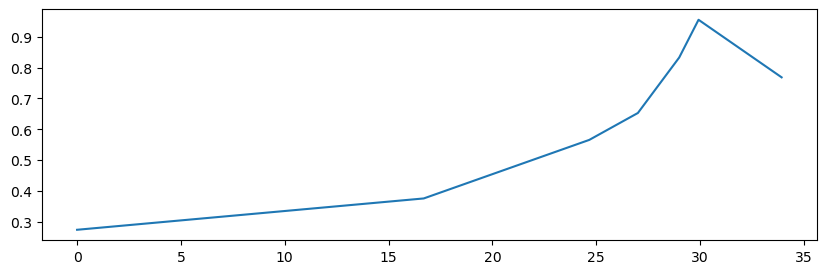

In [288]:
max_NLI_label
max_NLI_vals

TP_station = 0
wr01_station = 16.69
wr02_station = 24.66
wr03_station = 27
wr04_station = 28.99 
wr06_station = 29.92
wr07_station = wr06_station + 4

max_NLI_station = [TP_station, wr01_station, wr02_station, wr03_station, wr04_station, wr06_station, wr07_station]

fig, ax = plt.subplots(figsize=(10,3))
ax.plot(max_NLI_station, max_NLI_vals);

In [289]:
max_NLI_vals
max_NLI = []
for i in range(len(max_NLI_vals)):
    value = float(max_NLI_vals[i])
    max_NLI.append(value)

max_NLI

[0.2750517029179159,
 0.37646134310612434,
 0.5659368831672231,
 0.6530247135038454,
 0.8326290790325112,
 0.9546788006513345,
 0.7683830339781177]